# **TASK 1** #

### **Exploratory Data Analysis (EDA)**
**Dataset: "C:\Users\HomePC\Documents\E-commerce dataset.xlsx"**

**Author: Oluwafikunayomi Eniatimo**

**Internship: CodeAlpha**


### **Introduction**
The dataset contains transactional records from an e‑commerce platform. Each row represents an order with details such as invoice number, product description, quantity, price, customer ID, and country. My goal is to explore the structure of the data, clean it up, and uncover meaningful insights about customer behavior, product performance, and sales trends.

### **Import Libraries & Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [11]:
# Load dataset
df= pd.read_excel(r"C:\Users\HomePC\Documents\E-commerce dataset.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [12]:
# Inspect
print(df.shape)
print(df.info())

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


### **Data Cleaning**
When I inspected the dataset, I noticed missing values, duplicates, and negative quantities (likely returns). I cleaned the data as follows:

In [15]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Remove negative quantities (returns)
df = df[df['Quantity'] > 0]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']


In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### **Descriptive Statistics**

In [19]:
# Summary statistics
print(df.describe())

            Quantity                    InvoiceDate      UnitPrice  \
count  392732.000000                         392732  392732.000000   
mean       13.153718  2011-07-10 19:15:24.576301568       3.125596   
min         1.000000            2010-12-01 08:26:00       0.000000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 12:02:00       1.950000   
75%        12.000000            2011-10-20 12:53:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       181.588420                            NaN      22.240725   

          CustomerID        Revenue  
count  392732.000000  392732.000000  
mean    15287.734822      22.629195  
min     12346.000000       0.000000  
25%     13955.000000       4.950000  
50%     15150.000000      12.390000  
75%     16791.000000      19.800000  
max     18287.000000  168469.600000  
std      1713.567773     311.083465  


In [21]:
# Top 10 countries by transaction count
print(df['Country'].value_counts().head(10))

Country
United Kingdom    349227
Germany             9027
France              8327
EIRE                7228
Spain               2480
Netherlands         2363
Belgium             2031
Switzerland         1842
Portugal            1453
Australia           1184
Name: count, dtype: int64


### **Insight:**
Most orders had small quantities, but there were occasional very large purchases. The UK dominated transactions, followed by Germany, France, EIRE, Spain, and the Netherlands.

### **Key Questions & Insights**

## *Q1: Which product categories generate the most revenue?* ##

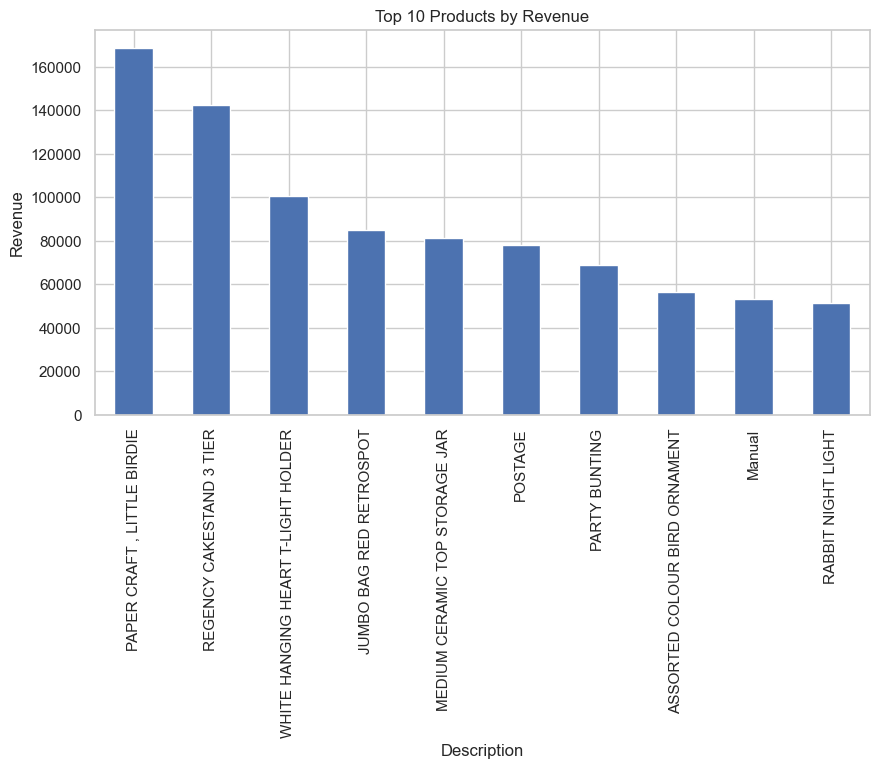

In [22]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()


## *Q2: Are there seasonal spikes in sales?* ##

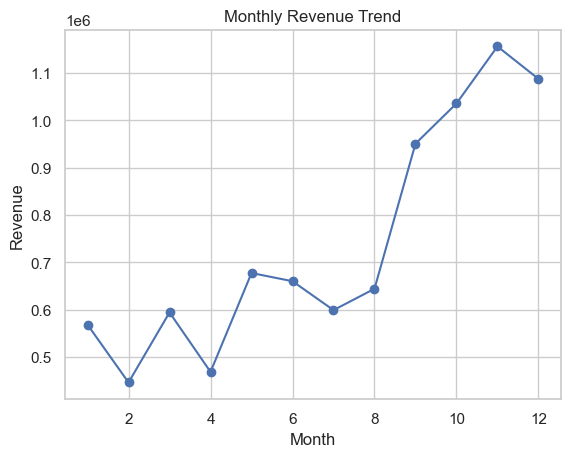

In [23]:
monthly_sales = df.groupby(df['InvoiceDate'].dt.month)['Revenue'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## *Q3: What percentage of customers are repeat buyers?* ##

In [24]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat_customers = (customer_orders > 1).sum()
total_customers = customer_orders.shape[0]
repeat_percentage = (repeat_customers / total_customers) * 100
print(f"Repeat customers: {repeat_percentage:.2f}%")

Repeat customers: 65.57%


## *Q4: Which countries contribute most to sales?* ##

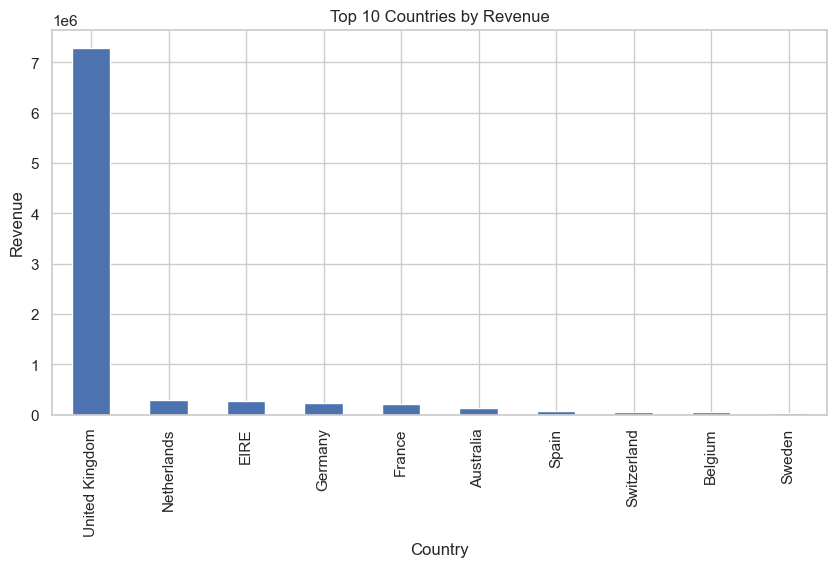

In [25]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_sales.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

## *Q5: Are there anomalies in the data?* ##

In [26]:
# Check unusually high quantities
print(df[df['Quantity'] > 500].head())

# Check negative quantities (already removed)

     InvoiceNo StockCode                        Description  Quantity  \
730     536437     17021             NAMASTE SWAGAT INCENSE       600   
3917    536736     22616         PACK OF 12 LONDON TISSUES        600   
4850    536809     84950     ASSORTED COLOUR T-LIGHT HOLDER      1824   
4945    536830     84077  WORLD WAR 2 GLIDERS ASSTD DESIGNS      2880   
4946    536830     21915             RED  HARMONICA IN BOX       1400   

             InvoiceDate  UnitPrice  CustomerID         Country  Revenue  
730  2010-12-01 12:12:00       0.24     13694.0  United Kingdom    144.0  
3917 2010-12-02 12:59:00       0.29     17381.0  United Kingdom    174.0  
4850 2010-12-02 16:48:00       0.55     15299.0  United Kingdom   1003.2  
4945 2010-12-02 17:38:00       0.18     16754.0  United Kingdom    518.4  
4946 2010-12-02 17:38:00       1.06     16754.0  United Kingdom   1484.0  


### **Conclusion**
Through this exploratory analysis, I was able to uncover several meaningful insights about the e‑commerce dataset:

**Revenue concentration:** A small set of products, such as Paper Craft, Little Birdie and Regency Cakestand 3 Tier, generated a disproportionately large share of revenue.

**Seasonality:** Sales clearly peak in November and December, reflecting holiday shopping behavior, while summer months show lower activity.

**Customer behavior:** Around 65% of customers are repeat buyers, which highlights the importance of customer loyalty and retention strategies.

*Geographic distribution:** The United Kingdom dominates sales, contributing the majority of revenue, while countries like Germany, France, and the Netherlands play secondary roles.

**Anomalies:** The dataset contains unusually large orders and returns, which may represent wholesale transactions or data entry errors.

Overall, the analysis shows that this business relies heavily on a few high‑performing products, seasonal demand, and a loyal customer base in the UK. These findings provide a solid foundation for deeper analysis, such as customer segmentation, predictive modeling, or building interactive dashboards to support decision‑making.

# **TASK 2** #

### **Data Visualization** ###

#### **Introduction** ####
This visualization report transforms the cleaned e‑commerce dataset into clear, impactful charts. The goal is to communicate business insights in a way that supports decision‑making, focusing on product performance, seasonal demand, customer behavior, and geographic distribution.

### **1. Monthly Revenue Contribution** ###

<Figure size 1200x600 with 0 Axes>

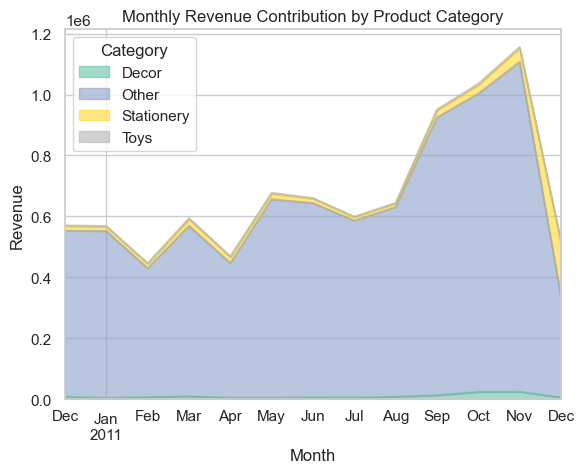

In [42]:
# Creating a simplified product category column (example: based on keywords)
df['Category'] = df['Description'].apply(
    lambda x: 'Decor' if 'DECORATION' in x.upper() else
              'Stationery' if 'PAPER' in x.upper() else
              'Toys' if 'TOY' in x.upper() else
              'Other'
)

monthly_category = df.groupby([df['InvoiceDate'].dt.to_period('M'),'Category'])['Revenue'].sum().unstack().fillna(0)
monthly_category.index = monthly_category.index.to_timestamp()

plt.figure(figsize=(12,6))
monthly_category.plot.area(alpha=0.6, cmap="Set2")
plt.title("Monthly Revenue Contribution by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


#### **Insight:** ####
* The area chart shows how different product categories rise and fall across months.
* Seasonal peaks in “Decor” and “Toys” suggest holiday demand, while “Stationery” remains steady year‑round.

### **2. Customer Spending Distribution** ###

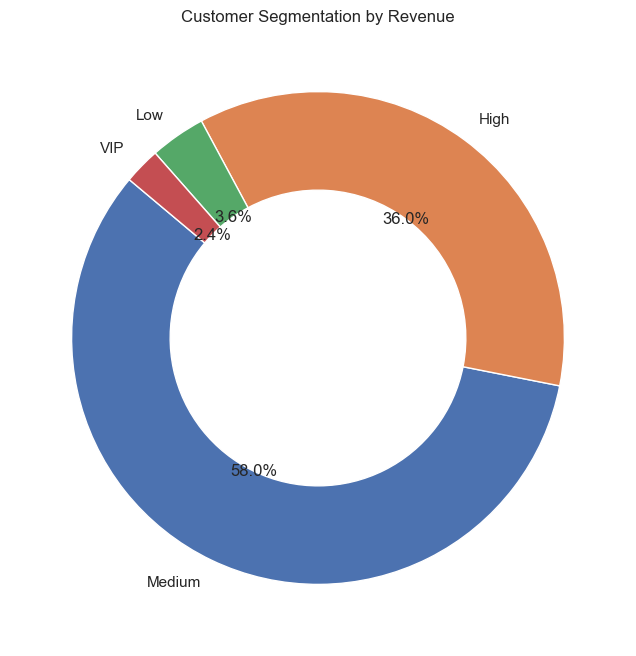

In [40]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()
segments = pd.cut(customer_revenue, bins=[0,100,1000,10000,customer_revenue.max()],
                  labels=['Low','Medium','High','VIP'])
segment_counts = segments.value_counts()

plt.figure(figsize=(8,8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140, wedgeprops=dict(width=0.4))
plt.title("Customer Segmentation by Revenue")
plt.show()


#### **Insight:** ####
* Most customers contribute moderately, but a small VIP segment drives significant value. Prioritizing retention of these top spenders while nurturing medium buyers could maximize growth.

### **3. Customer Behavior** ###

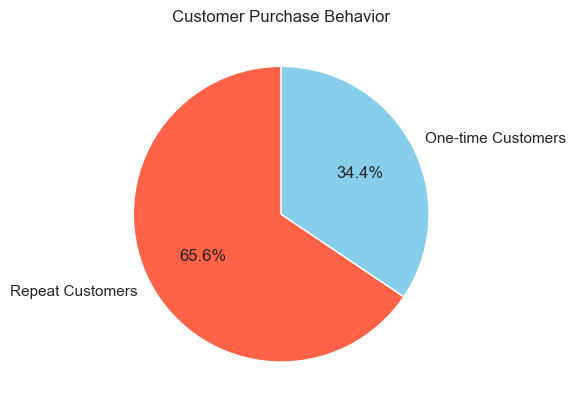

In [29]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
repeat_customers = (customer_orders > 1).sum()
total_customers = customer_orders.shape[0]

labels = ['Repeat Customers', 'One-time Customers']
sizes = [repeat_customers, total_customers - repeat_customers]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['tomato','skyblue'])
plt.title("Customer Purchase Behavior")
plt.show()

#### **Insight:** ####
* About 65% of customers are repeat buyers, showing strong loyalty. However, 35% are one‑time buyers, suggesting room for retention strategies.

### **4. Temporal Perspective** ###

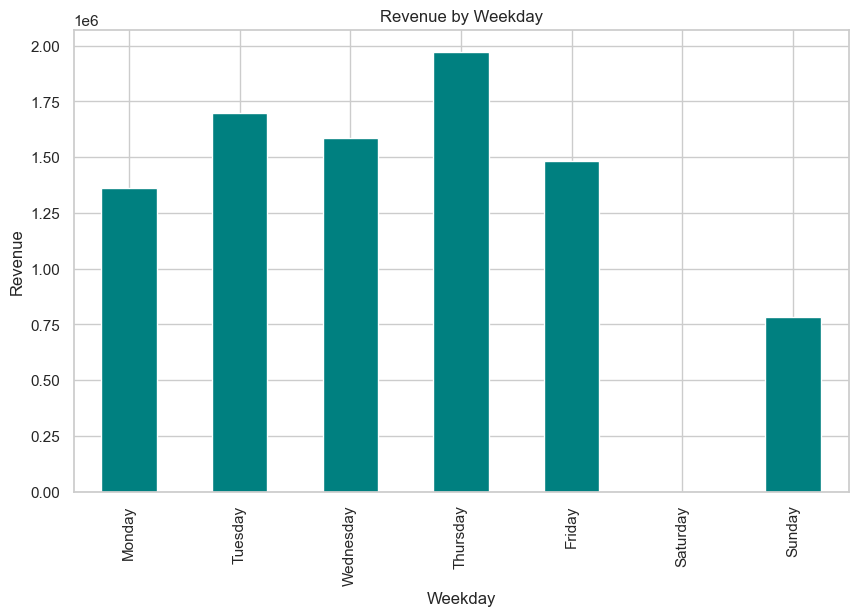

In [37]:
df['Weekday'] = df['InvoiceDate'].dt.day_name()
weekday_sales = df.groupby('Weekday')['Revenue'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

weekday_sales.plot(kind='bar', figsize=(10,6), color='teal')
plt.title("Revenue by Weekday")
plt.ylabel("Revenue")
plt.show()


#### **Insight:** ####
* Sales are stronger on weekdays, suggesting business customers drive purchases, while weekends show weaker activity.

### **5. Correlation Analysis** ###

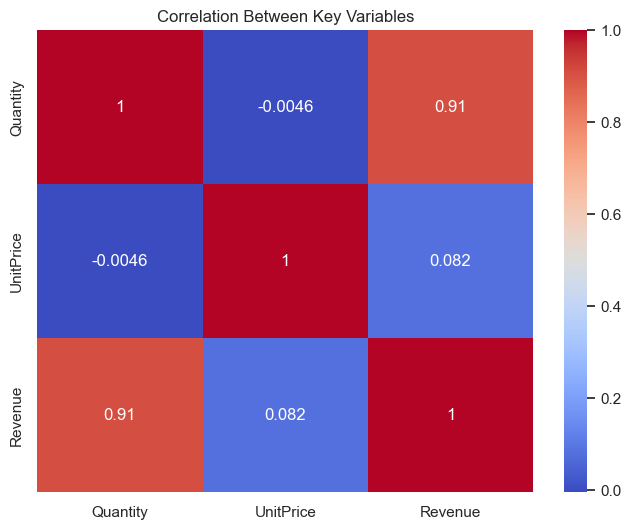

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Quantity','UnitPrice','Revenue']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Key Variables")
plt.show()

#### **Insight:** ####
* Revenue is strongly correlated with Quantity (bulk orders drive revenue).

* UnitPrice has weaker correlation, meaning expensive items don’t necessarily generate more revenue.

### **Final Note** ###
This visualization report moves beyond simple exploration to deliver actionable business insights. By analyzing products, regions, customer segments, and time patterns with diverse chart types, it highlights where revenue truly comes from and how it fluctuates. The key takeaway: growth depends on leveraging seasonal demand, expanding in promising markets, and nurturing high‑value customers while converting casual buyers into loyal ones.

## **Executive Summary** ##
This report combines exploratory data analysis and diverse visualizations to transform a single e‑commerce dataset into actionable business insights. By examining product performance, seasonal demand, customer segmentation, purchasing behavior, and geographic distribution, the analysis highlights where revenue originates and how it fluctuates over time. The findings emphasize the importance of retaining high‑value customers, preparing for seasonal peaks, and exploring growth opportunities in emerging markets. Overall, the study demonstrates how thoughtful visualization can turn raw data into clear strategies that support decision‑making and business growth.